### 분할정복과 LLM 에이전트

LLM 에이전트는 복잡한 문제를 해결하기 위해 컴퓨터 공학의 **분할정복**(Divide and conquer algorithm) 패러다임을 사용한다. 이는 문제를 **계획**, **실행**, **통합**하는 세 단계로 나누어 처리하는 방식이다.
**ReAct**와 **Plan-and-Execute**는 이 원리를 구현한 대표적인 **패턴**이다.

---

### ReAct (Reasoning and Acting)

**ReAct**는 **추론**과 **행동**을 반복하는 패턴이다. LLM은 **생각**(Thought)으로 다음 **행동**(Action)을 결정하고, 행동의 결과인 **관찰**(Observation)을 바탕으로 다시 새로운 생각을 한다.

* **특징**: 실시간으로 상황을 판단하고 다음 단계를 유동적으로 결정한다. 이는 예측 불가능한 문제에 강하며, 긴 추론 과정 중 오류 발생 시 경로를 수정할 수 있는 유연성을 제공한다.

---

### Plan-and-Execute

**Plan-and-Execute**는 먼저 전체 **계획**을 한 번에 수립한 후 순서대로 하위 작업을 **실행**하는 패턴이다.

* **특징**: LLM이 초기에 모든 단계를 명시적으로 나열하고, 이 계획에 따라 각 하위 작업을 순차적으로 실행한다. 체계적이고 구조화된 작업에 효율적이며, 진행 상황을 명확하게 파악할 수 있다.

---

### 핵심 차이점

두 패턴의 가장 큰 차이점은 **계획 수립 시점**과 **유연성**에 있다.

* **ReAct**: 매 단계마다 다음 행동을 결정하는 **동적이고 반응적인** 방식이다.
* **Plan-and-Execute**: 초기에 전체 계획을 수립하고 순차적으로 실행하는 **정적이고 계획적인** 방식이다.

### **ReAct 패턴** 예제

#### ReAct 패턴의 구현 요소

ReAct 패턴의 핵심은 **추론(Reasoning)**과 **행동(Acting)**을 반복적으로 수행하는 **순환 구조**이다.

* **생각 (Reasoning) 및 행동 (Acting) 결정**: `call_model` 노드는 사용자의 메시지를 받아 LLM(Gemini)을 호출, LLM은 사용자의 질문에 답하기 위해 필요한 도구(tool) 호출 결정, LLM의 추론과 도구 호출 결정은 ReAct 패턴의 **Reasoning**에 해당함.
* **행동 실행 (Acting)**: LLM이 `tool_calls`를 결정하면, `call_conditional_edges`는 흐름을 `tool_node`로 전환. `tool_node`는 LLM이 결정한 도구(`get_weather`)를 실제 실행. 이는 **Acting**에 해당함.
* **관찰 (Observation) 및 반복**: `tool_node`의 실행 결과(날씨 정보)는 `call_model`로 다시 전달됩니다. LLM은 이 결과를 새로운 **관찰**로 인식하고, 이를 바탕으로 최종 답변을 생성하거나 추가적인 행동 결정. 이 순환 과정은 ReAct의 반복적인 **루프**를 나타냄.

#### 코드의 ReAct 구조

* `graph_builder.add_edge(START, "call_model")`: 시작점에서 LLM을 호출하여 추론을 시작합니다.
* `graph_builder.add_conditional_edges(...)`: LLM의 추론 결과(`tool_calls` 유무)에 따라 **도구 실행(`tool_node`)** 또는 **최종 답변 생성(`END`)**으로 분기합니다.
* `graph_builder.add_edge("tool_node", "call_model")`: 도구 실행이 끝나면 그 결과를 가지고 다시 LLM으로 돌아와 다음 추론을 진행합니다.

이 구조는 `Thought-Action-Observation`의 반복적인 루프를 통해 복잡한 문제를 해결하는 전형적인 ReAct 패턴의 동작 방식과 일치한다.

In [1]:
# uv add geopy
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [2]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [3]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.09763240814208984, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2026-06-12T21:30", "interval": 900, "temperature": 18.8, "windspeed": 2.7, "winddirection": 293, "is_day": 1, "weathercode": 0}}'

In [4]:
# uv add python-dotenv langchain langchain_google_genai
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv(override=True)

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
).bind_tools(tools) # 반드시 도구를 모델에 바인딩해야 함

In [5]:
from langgraph.graph import MessagesState

def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

In [6]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리

tool_node = ToolNode([get_weather])

In [7]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("call_model", call_model)
graph_builder.add_node("tool_node", tool_node)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
    {"tool_node": "tool_node", END: END},
)
graph_builder.add_edge("tool_node", "call_model")

graph = graph_builder.compile()

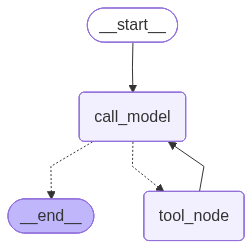

In [8]:
graph

In [9]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = graph.invoke({"messages": [HumanMessage(content=query)]})

result

날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='ca2f9c3a-7ffe-4ff5-96dc-3fd6e4ff0df4'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}, '__gemini_function_call_thought_signatures__': {'2cd9c078-4ab2-43dc-a1ef-ed036c7e8704': 'CusBAQw51sdGPEy61fkQFgZRCMxJ8yd0X9Lh6uL4ziY0AQple9j2GavlgK72tddqI9GVG9rhM0FMkzdqxXfZVM1u8KqX+6PyydSOTRwX3qBea+gyBCS/LApfg9TgFSh1W4PMwRAewj6AO9GPm9Z2IipuLGpOlqd8EAbfY4IpmhHB+bAYugQVDTZPhfgb6zTG6gBj5cZCRZfQgtHVHFRtTrHBRIRAdYRZz1v6l7GH1accnIJ0Oyrki9xcKm9Hedf7+wsY/CvOW2rNmbYgl9GUeujLe5VCOQbXWLyK7NDF6z3P7hpmPsJITdgNfGJ6/w=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebdc2-86fb-79d1-b6c1-7c71bf606144-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': '2cd9c078-4ab2-43dc-a1ef-ed036c7e8704', 'type': 'tool_call

In [10]:
result['messages'][-1].content

'부산의 현재 날씨는 섭씨 18.8도이며, 바람은 초속 2.7km/h로 서북서 방향으로 불고 있습니다. 맑은 날씨입니다.'

In [11]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = graph.invoke({"messages": [HumanMessage(content=query)]})

result

{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='ec95126a-059d-41f7-84cf-5d0909e4f72f'),
  AIMessage(content=[{'type': 'text', 'text': '랭그래프는 랭체인(LangChain)을 기반으로 하는 라이브러리로, 여러 언어 모델(LLM) 호출과 도구 사용을 조합하여 복잡한 에이전트(Agent) 워크플로우를 구축하고 시각화하는 데 도움을 줍니다. 상태를 관리하고, 조건부 로직을 통해 다음 단계를 결정하며, 순환(loop)을 처리하는 등의 기능을 제공하여 대화형 에이전트나 복잡한 추론 시스템을 만들 때 유용합니다.', 'extras': {'signature': 'CswBAQw51sc4dqKKlGUGxzhxiTu5xNf41bCtYRyilh8psPZwUlmWef9jQ/5yeNZb1PaiDf4N0YJCRZIYoJbr8Hp+1ojXOGozeJortDkGlgJd4dQhjKPUPVNwwqoqrnQq2KbE94844szCfBT0rgcN+LLopZGfk3BqsUQvmq5FH941U0UOnGOsWdvEklkoMwDAxD29nCGdUiNoIqZsFzJfg8Lxc+C32CrJRgsCoMsTCfncGfGXKelZyCnsRxQVetsP3QbVzrvfBlKUmHLwZVRE'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebdc2-960b-70f1-959c-7dcfb8e84217-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 64, 'ou

In [12]:
print(result['messages'][-1].content)

[{'type': 'text', 'text': '랭그래프는 랭체인(LangChain)을 기반으로 하는 라이브러리로, 여러 언어 모델(LLM) 호출과 도구 사용을 조합하여 복잡한 에이전트(Agent) 워크플로우를 구축하고 시각화하는 데 도움을 줍니다. 상태를 관리하고, 조건부 로직을 통해 다음 단계를 결정하며, 순환(loop)을 처리하는 등의 기능을 제공하여 대화형 에이전트나 복잡한 추론 시스템을 만들 때 유용합니다.', 'extras': {'signature': 'CswBAQw51sc4dqKKlGUGxzhxiTu5xNf41bCtYRyilh8psPZwUlmWef9jQ/5yeNZb1PaiDf4N0YJCRZIYoJbr8Hp+1ojXOGozeJortDkGlgJd4dQhjKPUPVNwwqoqrnQq2KbE94844szCfBT0rgcN+LLopZGfk3BqsUQvmq5FH941U0UOnGOsWdvEklkoMwDAxD29nCGdUiNoIqZsFzJfg8Lxc+C32CrJRgsCoMsTCfncGfGXKelZyCnsRxQVetsP3QbVzrvfBlKUmHLwZVRE'}}]
